In [7]:
import pandas as pd
from pathlib import Path

In [8]:
read_file = "../combinedrids/combined_unique_hashed_rid.parquet" # change accordingly
df = pd.read_parquet(read_file, engine="pyarrow")

# ensure datetime
df["trip_start_time"] = pd.to_datetime(df["trip_start_time"])

# localize as UTC, then convert to IST
df["trip_start_time_ist"] = (
    df["trip_start_time"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Asia/Kolkata")
)

df["trip_start_time_ist"] = df["trip_start_time_ist"].dt.tz_localize(None)

# ensure datetime
df["trip_end_time"] = pd.to_datetime(df["trip_end_time"])

# localize as UTC, then convert to IST
df["trip_end_time_ist"] = (
    df["trip_end_time"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Asia/Kolkata")
)

df["trip_end_time_ist"] = df["trip_end_time_ist"].dt.tz_localize(None)


df = df.drop(columns=["trip_start_time", "trip_end_time"])


In [9]:
df["trip_start_time"] = pd.to_datetime(df["trip_start_time_ist"])
df["trip_end_time"] = pd.to_datetime(df["trip_end_time_ist"])

# split into date, day, time
df["date"] = df["trip_start_time"].dt.date
df["day"] = df["trip_start_time"].dt.day_name()
df["time_start"] = df["trip_start_time"].dt.time
df["time_end"] = df["trip_end_time"].dt.time

# df["time_start"] = df["trip_start_time"].dt.time
df["time"] = pd.to_datetime(df["time_start"].astype(str), format="%H:%M:%S")
df["hour"] = df["time"].dt.hour

bins = [0, 6, 12, 18, 21, 24]
labels = ["Late Night", "Morning", "Afternoon", "Evening", "Night"]

df["day_part"] = pd.cut(
    df["hour"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)



df["time_start"]

0          08:03:58
1          17:45:07
2          17:16:21
3          12:31:46
4          20:53:24
             ...   
1652094    08:58:22
1652095    13:03:37
1652096    09:21:52
1652097    11:41:51
1652098    21:27:19
Name: time_start, Length: 1652099, dtype: object

In [10]:
df

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,chargeable_distance,fare,traveled_distance,rider_id,...,trip_end_time_ist,trip_start_time,trip_end_time,date,day,time_start,time_end,time,hour,day_part
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,19641.0,325.0,19249.8,d865efa7-e800-4de0-baa4-517ad24794c8,...,2025-07-30 08:46:33,2025-07-30 08:03:58,2025-07-30 08:46:33,2025-07-30,Wednesday,08:03:58,08:46:33,1900-01-01 08:03:58,8,Morning
1,524b2080d5a8ec3578ff05f2961094254b91c1087d06e3...,3c6a15db3ef6cf7cd0e0681b7a8b75592bcedd0022f9b1...,12.981527,77.597252,12.901654,77.539214,14455.0,258.0,14455.0,bd84cf10-2a9c-43e2-922b-247e5def1388,...,2025-07-30 18:41:29,2025-07-30 17:45:07,2025-07-30 18:41:29,2025-07-30,Wednesday,17:45:07,18:41:29,1900-01-01 17:45:07,17,Afternoon
2,830b84022e5af06037fcd07d96c5f48955e409759b50a8...,8fb140fe1ca2fb78ae5be9c6e6dbff912acb3ecc97d6f0...,13.029167,77.540034,13.079102,77.633052,16787.0,272.0,16787.0,b34bedae-fe34-421d-9042-0b7972f92d30,...,2025-07-30 18:16:05,2025-07-30 17:16:21,2025-07-30 18:16:05,2025-07-30,Wednesday,17:16:21,18:16:05,1900-01-01 17:16:21,17,Afternoon
3,c44b3043b35d7680c0847ab499caf10d00fab9a5ac38ff...,62c3f6e5997e027b10a1958aec48602db5d297a185718f...,13.012023,77.667913,13.017949,77.673293,1306.0,60.0,1306.0,1ad46be8-9007-4970-b97c-ace91831faa4,...,2025-07-30 12:38:24,2025-07-30 12:31:46,2025-07-30 12:38:24,2025-07-30,Wednesday,12:31:46,12:38:24,1900-01-01 12:31:46,12,Afternoon
4,d3fd5600a6eb27b235a6b3d65a191fc360bf71de1ba4df...,e5f38304ee1e679b3ccef580e5c23d164ed2a48d92d789...,12.993979,77.577726,13.014653,77.574388,4468.0,117.0,4468.0,16e1214e-9687-4cad-b4dc-b3ae9ae28afb,...,2025-07-30 21:03:42,2025-07-30 20:53:24,2025-07-30 21:03:42,2025-07-30,Wednesday,20:53:24,21:03:42,1900-01-01 20:53:24,20,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1652094,483bfd4ffb68aaaed509794394f0d87c4172a3d2aa620d...,6ee797fede0cd4574d6b8839637b2e7efddfbb36c2badb...,12.972339,77.649057,12.927995,77.621247,7038.0,177.0,7039.0,5521ce25-29f1-4731-a4ab-cc59d293d300,...,2025-08-12 09:29:44,2025-08-12 08:58:22,2025-08-12 09:29:44,2025-08-12,Tuesday,08:58:22,09:29:44,1900-01-01 08:58:22,8,Morning
1652095,abf50837314e05ce565da1311efe0a2f33e3fdb2ea1917...,fa560d9a9a8409d1e8e8e5c3ce61d15c4a6511bbcc9046...,13.064868,77.596003,13.094877,77.594553,4064.0,93.0,4064.0,9ec7e4b8-e300-47e2-bd6e-156eefc83d7c,...,2025-08-12 13:16:30,2025-08-12 13:03:37,2025-08-12 13:16:30,2025-08-12,Tuesday,13:03:37,13:16:30,1900-01-01 13:03:37,13,Afternoon
1652096,16d4a5ac734682c5df2f4ec807ffd44f29b80232cb4613...,e0898b4e85db419d024715b544adbfb6ce39409bac75fe...,12.936313,77.574832,12.897510,77.598975,7154.0,159.0,7154.0,63f5d958-53ac-480e-94a9-4f352f1bf3db,...,2025-08-12 09:51:01,2025-08-12 09:21:52,2025-08-12 09:51:01,2025-08-12,Tuesday,09:21:52,09:51:01,1900-01-01 09:21:52,9,Morning
1652097,a63648acf955cda62e6ff353b07000b8da474b0e12ddc3...,cd72b33a39cdeb0bcc0712cb233cad057cd726c34a6880...,12.882419,77.546706,12.906522,77.597740,7029.0,157.0,7029.0,f61e25f7-7e3a-48e4-b94b-d44f0167e7a7,...,2025-08-12 12:05:10,2025-08-12 11:41:51,2025-08-12 12:05:10,2025-08-12,Tuesday,11:41:51,12:05:10,1900-01-01 11:41:51,11,Morning


In [11]:
df.nunique(dropna=True)

hashed_rid             1652099
hashed_driver_id         71635
trip_start_lat          955557
trip_start_lon          953869
trip_end_lat            971519
trip_end_lon            969785
chargeable_distance      32590
fare                       931
traveled_distance       278403
rider_id                624329
trip_start_time_ist     712082
trip_end_time_ist       714177
trip_start_time         712082
trip_end_time           714177
date                        15
day                          7
time_start               77661
time_end                 77622
time                     77661
hour                        24
day_part                     5
dtype: int64

In [12]:
print(df['date'].value_counts())
print(df['day'].value_counts())
print(df['hour'].value_counts())
print(df['day_part'].value_counts())

date
2025-08-02    137634
2025-08-11    135366
2025-08-12    130076
2025-08-06    126994
2025-08-09    126420
2025-07-31    124610
2025-08-07    124257
2025-08-01    121406
2025-07-30    119455
2025-08-08    118152
2025-08-10    116416
2025-08-05     97012
2025-08-03     94824
2025-08-04     78402
2025-08-13      1075
Name: count, dtype: int64
day
Saturday     264054
Thursday     248867
Wednesday    247524
Friday       239558
Tuesday      227088
Monday       213768
Sunday       211240
Name: count, dtype: int64
hour
18    128084
17    127095
16    124532
19    122299
9     114717
10    112659
15    111717
14    104218
12    102710
13    102189
11    101797
20     96400
8      92120
21     62321
7      52440
22     35200
6      20146
23     15443
5       8470
0       7532
1       4689
4       2629
2       1414
3       1278
Name: count, dtype: int64
day_part
Afternoon     672461
Morning       493879
Evening       346783
Night         112964
Late Night     26012
Name: count, dtype: int64


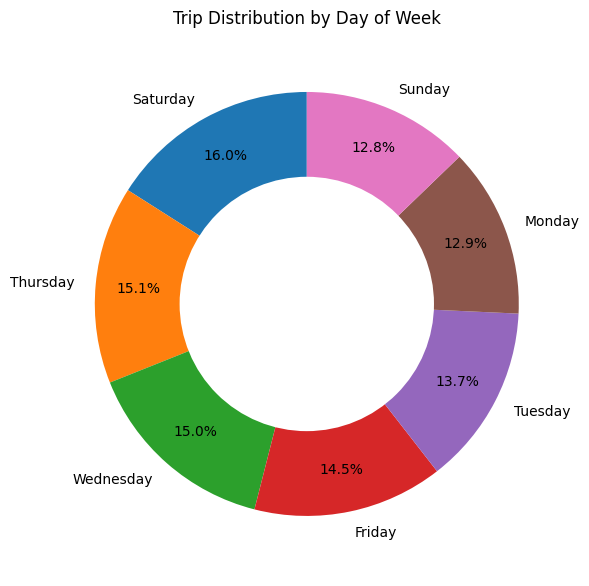

In [8]:
import matplotlib.pyplot as plt

# your data
counts = {
    "Saturday": 264054,
    "Thursday": 248867,
    "Wednesday": 247524,
    "Friday": 239558,
    "Tuesday": 227088,
    "Monday": 213768,
    "Sunday": 211240
}
    
labels = list(counts.keys())
sizes = list(counts.values())

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)

# donut hole
centre_circle = plt.Circle((0, 0), 0.6, fc="white")
ax.add_artist(centre_circle)

ax.set_title("Trip Distribution by Day of Week")
ax.axis("equal")

plt.tight_layout()
Path("data_descrip_plots").mkdir(parents=True, exist_ok=True)
plt.savefig("data_descrip_plots/trip_distribution_by_weekday.png", dpi=300)
plt.show()


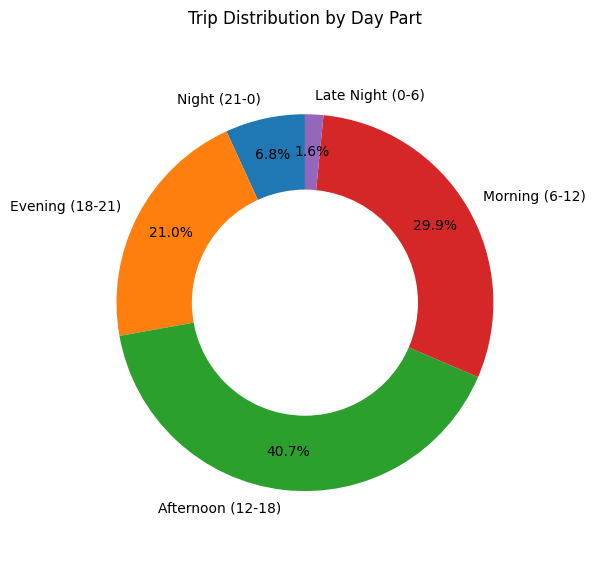

In [13]:
import matplotlib.pyplot as plt

# your data
counts = {
    "Night (21-0)": 112964,
    "Evening (18-21)": 346783,
    "Afternoon (12-18)": 672461,
    "Morning (6-12)": 493879,
    "Late Night (0-6)": 26012, # 112964+26012
}

labels = list(counts.keys())
sizes = list(counts.values())

fig, ax = plt.subplots(figsize=(6, 6))

# donut chart
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)

# draw center circle
centre_circle = plt.Circle((0, 0), 0.6, fc="white")
ax.add_artist(centre_circle)

ax.set_title("Trip Distribution by Day Part")
ax.axis("equal")  # keeps it circular

plt.tight_layout()
Path("data_descrip_plots").mkdir(parents=True, exist_ok=True)
plt.savefig("data_descrip_plots/trip_distribution_by_daypart.png", dpi=300)
plt.show()

In [14]:
# Monday=0, Sunday=6
df["weekday_num"] = df["trip_start_time"].dt.weekday
df["weekday_name"] = df["trip_start_time"].dt.day_name()

df["day_type"] = df["weekday_num"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [15]:
# day_map = {
#     5: "Saturday",
#     6: "Sunday"
# }

# df["day_type"] = df["weekday_num"].map(day_map).fillna("Weekday")


In [16]:
df_weekday = df[df["day_type"] == "Weekday"]
df_weekend = df[df["day_type"] == "Weekend"]


In [17]:
hourly_trend = (
    df.groupby(["day_type", "hour"])
      .size()
      .reset_index(name="trip_count")
)
hourly_trend

,day_type,hour,trip_count
0,Weekday,0,4381
1,Weekday,1,2337
2,Weekday,2,734
3,Weekday,3,803
4,Weekday,4,1876
5,Weekday,5,6053
6,Weekday,6,14895
7,Weekday,7,42197
8,Weekday,8,76231
9,Weekday,9,93746


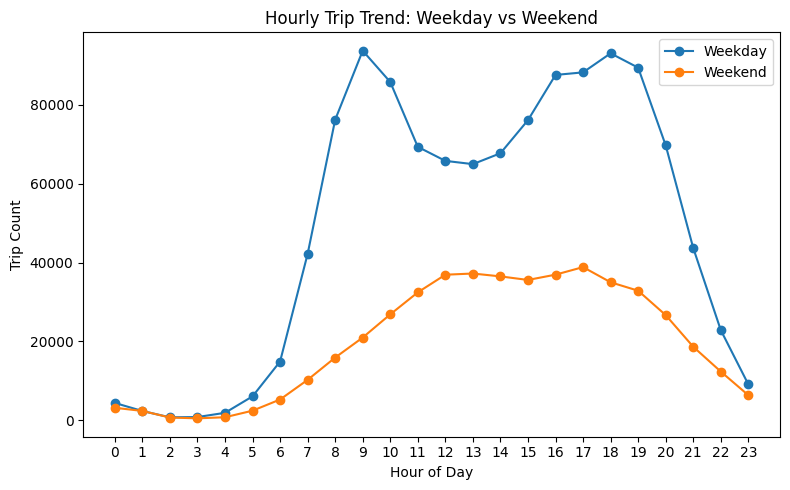

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for day_type, grp in hourly_trend.groupby("day_type"):
    plt.plot(
        grp["hour"],
        grp["trip_count"],
        marker="o",
        label=day_type
    )

plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.title("Hourly Trip Trend: Weekday vs Weekend")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# make a copy to avoid mutating original
hourly_norm = hourly_trend.copy()

hourly_norm.loc[hourly_norm["day_type"] == "Weekday", "trip_count"] /= 10
hourly_norm.loc[hourly_norm["day_type"] == "Weekend", "trip_count"] /= 4
hourly_norm

/tmp/ipykernel_250275/2395137573.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 438.1  233.7   73.4   80.3  187.6  605.3 1489.5 4219.7 7623.1 9374.6
 8580.4 6935.6 6579.7 6497.  6773.  7613.2 8760.2 8825.2 9308.6 8944.4
 6973.4 4368.8 2285.8  909.9]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hourly_norm.loc[hourly_norm["day_type"] == "Weekday", "trip_count"] /= 10


,day_type,hour,trip_count
0,Weekday,0,438.10
1,Weekday,1,233.70
2,Weekday,2,73.40
3,Weekday,3,80.30
4,Weekday,4,187.60
5,Weekday,5,605.30
6,Weekday,6,1489.50
7,Weekday,7,4219.70
8,Weekday,8,7623.10
9,Weekday,9,9374.60


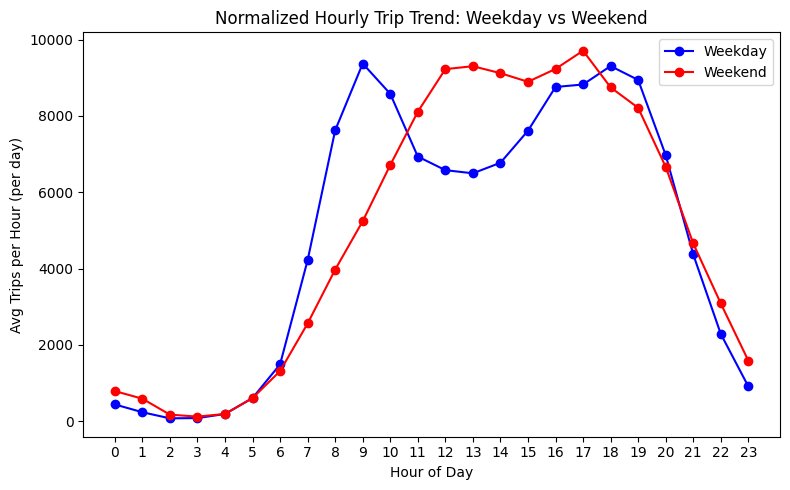

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

color_map = {
    "Weekday": "blue",
    "Weekend": "red"
}

for day_type, grp in hourly_norm.groupby("day_type"):
    plt.plot(
        grp["hour"],
        grp["trip_count"],
        marker="o",
        label=day_type,
        color=color_map.get(day_type, "black")
    )

plt.xlabel("Hour of Day")
plt.ylabel("Avg Trips per Hour (per day)")
plt.title("Normalized Hourly Trip Trend: Weekday vs Weekend")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
df["day_type2"] = df["weekday_num"].apply(
    lambda x: "Saturday" if x == 5 else "Sunday" if x == 6 else "Weekday"
)

In [22]:
df_weekday = df[df["day_type2"] == "Weekday"]
df_Saturday = df[df["day_type2"] == "Saturday"]
df_Sunday = df[df["day_type2"] == "Sunday"]

In [23]:
hourly_trend2 = (
    df.groupby(["day_type2", "hour"])
      .size()
      .reset_index(name="trip_count")
)
hourly_trend2

,day_type2,hour,trip_count
0,Saturday,0,1456
1,Saturday,1,1006
2,Saturday,2,316
3,Saturday,3,228
4,Saturday,4,402
...,...,...,...
67,Weekday,19,89444
68,Weekday,20,69734
69,Weekday,21,43688
70,Weekday,22,22858


In [24]:
# make a copy to avoid mutating original
hourly_norm2 = hourly_trend2.copy()

hourly_norm2.loc[hourly_norm2["day_type2"] == "Weekday", "trip_count"] /= 10
hourly_norm2.loc[hourly_norm2["day_type2"] == "Saturday", "trip_count"] /= 2
hourly_norm2.loc[hourly_norm2["day_type2"] == "Sunday", "trip_count"] /= 2
hourly_norm2

/tmp/ipykernel_250275/3025759895.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 438.1  233.7   73.4   80.3  187.6  605.3 1489.5 4219.7 7623.1 9374.6
 8580.4 6935.6 6579.7 6497.  6773.  7613.2 8760.2 8825.2 9308.6 8944.4
 6973.4 4368.8 2285.8  909.9]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hourly_norm2.loc[hourly_norm2["day_type2"] == "Weekday", "trip_count"] /= 10


,day_type2,hour,trip_count
0,Saturday,0,728.0
1,Saturday,1,503.0
2,Saturday,2,158.0
3,Saturday,3,114.0
4,Saturday,4,201.0
...,...,...,...
67,Weekday,19,8944.4
68,Weekday,20,6973.4
69,Weekday,21,4368.8
70,Weekday,22,2285.8


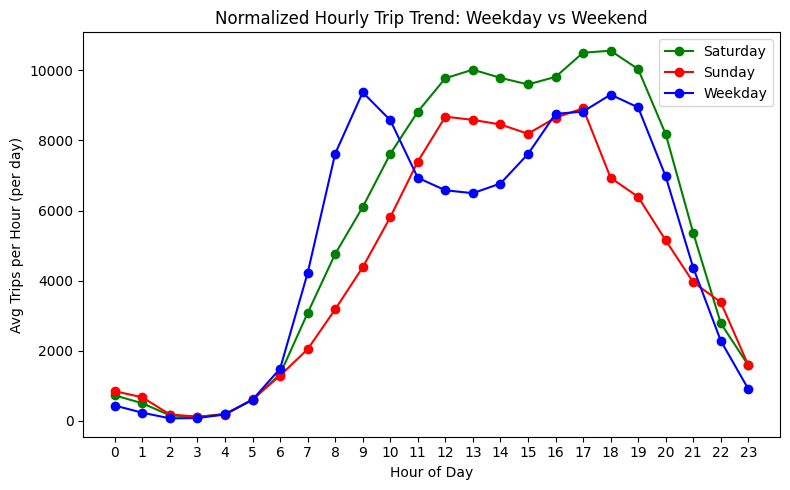

In [25]:
import matplotlib.pyplot as plt

color_map = {
    "Weekday": "blue",
    "Saturday": "green",
    "Sunday": "red"
}

plt.figure(figsize=(8, 5))

for day_type, grp in hourly_norm2.groupby("day_type2"):
    plt.plot(
        grp["hour"],
        grp["trip_count"],
        marker="o",
        label=day_type,
        color=color_map.get(day_type, "black")
    )

plt.xlabel("Hour of Day")
plt.ylabel("Avg Trips per Hour (per day)")
plt.title("Normalized Hourly Trip Trend: Weekday vs Weekend")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig("data_descrip_plots/Normalized Hourly Trip Trend: Weekday vs Weekend.png", dpi=300)
plt.show()



In [26]:
# daily_hourly = (
#     df
#     .groupby(["date", "hour"])
#     .size()
#     .reset_index(name="trip_count")
# )


In [27]:
# daily_hourly["norm_trip_count"] = (
#     daily_hourly
#     .groupby("date")["trip_count"]
#     .transform(lambda x: x / x.sum())
# )


In [28]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))

# for date, g in daily_hourly.groupby("date"):
#     plt.plot(g["hour"], g["trip_count"], alpha=0.6, label=str(date))

# # plt.xlabel("Hour of Day")
# # plt.ylabel("Normalized Trips")
# # plt.title("Normalized Hourly Trip Trend – Each Day")
# # plt.legend(ncol=2, fontsize=8)
# # plt.grid(False)
# # plt.tight_layout()
# plt.xlabel("Hour of Day")
# plt.ylabel("Avg Trips per Hour (per day)")
# plt.title("Hourly Daily Trip Trend")
# plt.xticks(range(0, 24))
# plt.legend()
# plt.tight_layout()
# plt.show()


In [29]:
# Ensure datetime
df["trip_start_time"] = pd.to_datetime(df["trip_start_time"])

df["weekday_num"] = df["trip_start_time"].dt.weekday  # Monday=0
df["weekday_name"] = df["trip_start_time"].dt.day_name()
df["hour"] = df["trip_start_time"].dt.hour


In [30]:
hourly_trend = (
    df.groupby(["weekday_name", "hour"])
      .size()
      .reset_index(name="trip_count")
)


In [31]:
# Count how many times each weekday appears
# day_counts = (
#     df.groupby("weekday_name")["trip_start_time"]
#       .nunique()
#       .to_dict()
# )

hourly_norm = hourly_trend.copy()
hourly_norm["trip_count"] = hourly_norm.apply(
    lambda row: row["trip_count"] / 2,
    axis=1
)


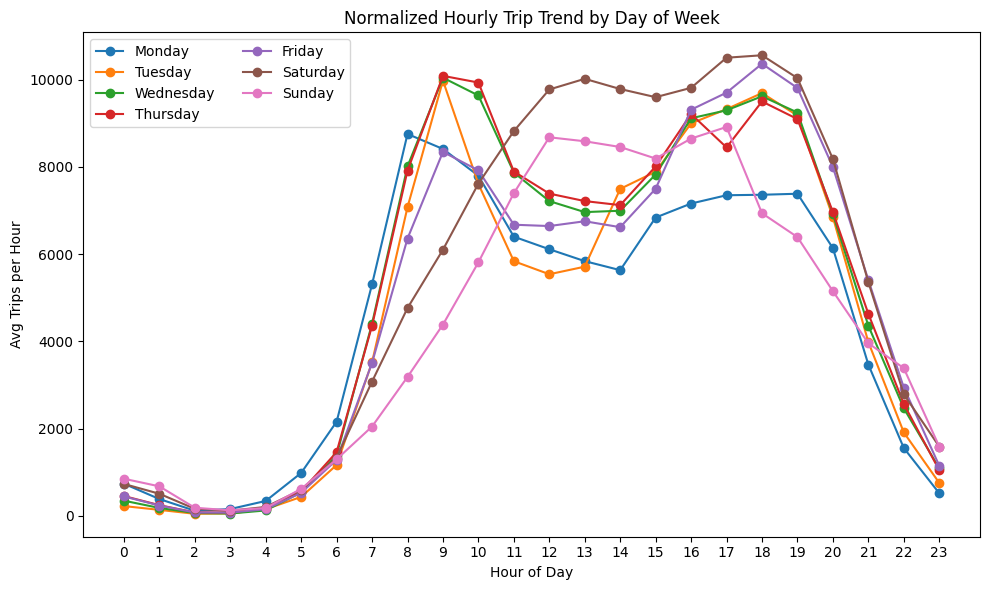

In [32]:
import matplotlib.pyplot as plt

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

color_map = {
    "Monday": "#1f77b4",
    "Tuesday": "#ff7f0e",
    "Wednesday": "#2ca02c",
    "Thursday": "#d62728",
    "Friday": "#9467bd",
    "Saturday": "#8c564b",
    "Sunday": "#e377c2",
}

plt.figure(figsize=(10, 6))

for day in weekday_order:
    grp = hourly_norm[hourly_norm["weekday_name"] == day]
    plt.plot(
        grp["hour"],
        grp["trip_count"],
        marker="o",
        label=day,
        color=color_map[day]
    )

plt.xlabel("Hour of Day")
plt.ylabel("Avg Trips per Hour")
plt.title("Normalized Hourly Trip Trend by Day of Week")
plt.xticks(range(0, 24))
plt.legend(ncol=2)
plt.tight_layout()
# save the figure to the outputs directory (create if not exists when running)
plt.savefig("data_descrip_plots/normalized_hourly_by_weekday.png", dpi=300)
plt.show()
